1. imported libraries for data loading and EDA.





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2. Dataset Overview for Data Understanding.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


3. Cleaning Column Lower_Case,Sneak_Casing.Names,Converting

In [4]:
df.columns = (
  df.columns
  .str.replace('([a-z])([A-Z])', r'\1_\2', regex=True)
  .str.replace(" ", "_")
  .str.lower()
)
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

4. Converting Total Charges to Numeric for Aggregated Calculations.

In [5]:
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

5. Checking Missing Values.

In [7]:
df.isnull().sum()

,0
customer_id,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0
online_security,0


6. Handling Missing Total Charges.
These rows represent customers with zero tenure.

In [8]:
null_total = df[df['total_charges'].isnull()]
null_total

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


7. This cells replaces missing total_charges values with 0.

In [9]:
df['total_charges'] = df['total_charges'].fillna(0)

In [10]:
df.isnull().sum().sum()

np.int64(0)

8. Exploring Categorial Features and ensures the data is clean,
standardized, and reliable before performing analysis or build
ing models.

In [11]:
for col in df.select_dtypes('object').columns:
    print(f"\n{col}")
    print(df[col].unique())


customer_id
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
['Female' 'Male']

partner
['Yes' 'No']

dependents
['No' 'Yes']

phone_service
['No' 'Yes']

multiple_lines
['No phone service' 'No' 'Yes']

internet_service
['DSL' 'Fiber optic' 'No']

online_security
['No' 'Yes' 'No internet service']

online_backup
['Yes' 'No' 'No internet service']

device_protection
['No' 'Yes' 'No internet service']

tech_support
['No' 'Yes' 'No internet service']

streaming_tv
['No' 'Yes' 'No internet service']

streaming_movies
['No' 'Yes' 'No internet service']

contract
['Month-to-month' 'One year' 'Two year']

paperless_billing
['Yes' 'No']

payment_method
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

churn
['No' 'Yes']


9. Creating New Churn Indicator Column for Calculations and Agg.

In [12]:
df['churn_count'] = df['churn'].map({'Yes': 1, 'No': 0})

In [13]:
df['churn_count'].sum()

np.int64(1869)

10. Removing Duplicate Records Based on Customer_id.

In [14]:
df.drop_duplicates(subset=['customer_id'],inplace = True)

In [16]:
df.shape

(7043, 22)

11. Creating Basic Charts for Analysis Showing Insights.

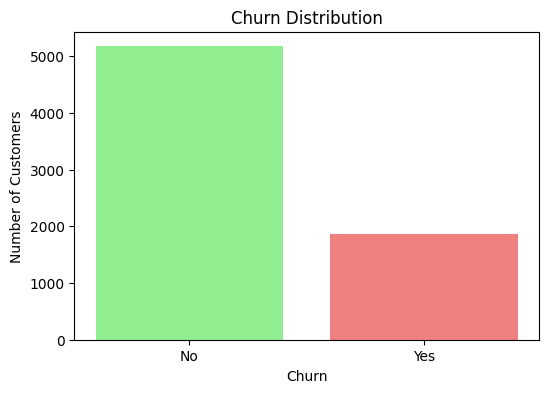

In [17]:
# Bar Chart
churn_counts = df['churn'].value_counts()
colors = ['lightgreen', 'lightcoral']

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index, churn_counts.values, color=colors)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

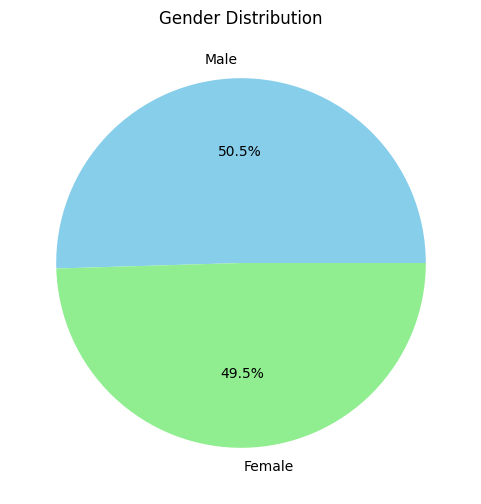

In [18]:
#Pie Chart
gender_counts = df['gender'].value_counts()
colors = ['skyblue', 'lightgreen']

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Gender Distribution')
plt.show()

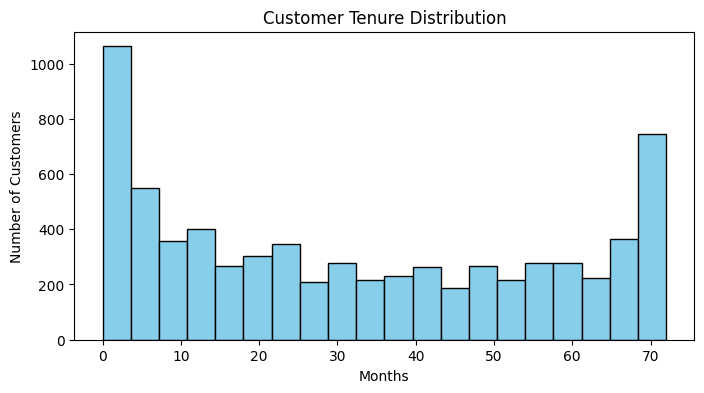

In [19]:
#Histogram
plt.figure(figsize=(8,4))
plt.hist(df['tenure'], bins=20, color='skyblue', edgecolor='black')
plt.title('Customer Tenure Distribution')
plt.xlabel('Months')
plt.ylabel('Number of Customers')
plt.show()

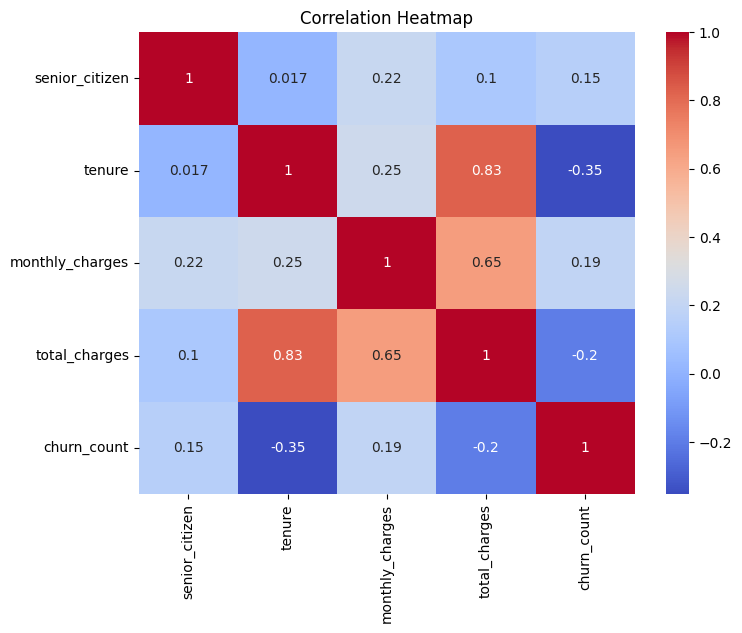

In [20]:
# Heat Map
numeric_cols = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [22]:
df.to_csv('cleaned_telco_customer_churn.csv', index=False)
print("Cleaned DataFrame saved to 'cleaned_telco_customer_churn.csv'")

Cleaned DataFrame saved to 'cleaned_telco_customer_churn.csv'


13. Downloading Cleaned Data in Working Directory.

In [23]:
from google.colab import files
files.download('cleaned_telco_customer_churn.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>